**LangGraph**

In [1]:
import os, sys
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root) 
from agents.flight.agent import build_flight_graph 

# Khởi tạo graph (cần dùng await vì hàm này là async)
graph = await build_flight_graph()

**Test**

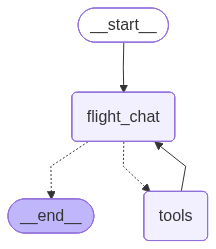

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	flight_chat(flight_chat)
	tools(tools)
	__end__([<p>__end__</p>]):::last
	__start__ --> flight_chat;
	flight_chat -.-> __end__;
	flight_chat -.-> tools;
	tools --> flight_chat;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



In [6]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph(xray=True).draw_mermaid_png()))
except Exception:
    pass
# 1. In ra mã nguồn Mermaid của graph
mermaid_code = graph.get_graph(xray=True).draw_mermaid()
print(mermaid_code)

In [2]:
from langchain_core.messages import AIMessage

# async def stream_graph_updates(inputs: dict):
#     async for event in graph.astream(inputs):
#         if "flight_chat" in event:
#             for msg in event["flight_chat"].get("messages", []):
#                 # In tham số tool — đây là chỗ cần check
#                 if isinstance(msg, AIMessage) and msg.tool_calls:
#                     for tc in msg.tool_calls:
#                         print("🔧 Tool:", tc["name"])
#                         print("📥 Args:", tc["args"])

#                 if hasattr(msg, "content") and msg.content:
#                     print("Assistant:", msg.content)

#         if "tools" in event:
#             for msg in event["tools"].get("messages", []):
#                 if hasattr(msg, "content") and msg.content:
#                     print("Tool Output:", msg.content)
config = {"configurable": {"thread_id": "user_12345"}}
async def stream_graph_updates(inputs: dict):
    # TRUYỀN CONFIG VÀO ĐÂY
    async for event in graph.astream(inputs, config=config):
        if "flight_chat" in event:
            for msg in event["flight_chat"].get("messages", []):
                if isinstance(msg, AIMessage) and msg.tool_calls:
                    for tc in msg.tool_calls:
                        print("🔧 Tool:", tc["name"])
                        print("📥 Args:", tc["args"])
                if hasattr(msg, "content") and msg.content:
                    print("Assistant:", msg.content)
        if "tools" in event:
            for msg in event["tools"].get("messages", []):
                if hasattr(msg, "content") and msg.content:
                    print("Tool Output:", msg.content)


In [ ]:
test_cases = [

    "Tôi muốn kiếm chuyen bay từ tp hcm đến Phú Yên ngày 21/7/2026."
]


for q in test_cases:
    print(f"\n🧑‍💻 User: {q}")
    inputs = {"messages": [{"role": "user", "content": q}]}
    print(inputs)
    await stream_graph_updates(inputs) 


🧑‍💻 User: Tôi muốn kiếm chuyen bay từ tp hcm đến Phú Yên ngày 21/7/2026.
{'messages': [{'role': 'user', 'content': 'Tôi muốn kiếm chuyen bay từ tp hcm đến Phú Yên ngày 21/7/2026.'}]}
🔧 Tool: search_one_way_flights_tool
📥 Args: {'destination': 'TBB', 'departure_date': '2026-07-21', 'origin': 'SGN'}
Tool Output: [{'type': 'text', 'text': '{\n  "source": "google-flights4.p.rapidapi",\n  "topFlights": [],\n  "otherFlights": [\n    {\n      "Offer_ID": "FL-941B73",\n      "price": 1236181,\n      "airline_code": "VN",\n      "airline_name": [\n        "Vietnam Airlines"\n      ],\n      "stops": null,\n      "duration_minutes": 90,\n      "departure_time": "17:35",\n      "departure_date": "2026-07-21",\n      "arrival_time": "19:05",\n      "arrival_date": "2026-07-21",\n      "departure_airport_code": "SGN",\n      "arrival_airport_code": "TBB",\n      "segments": [\n        {\n          "departure_airport_code": "SGN",\n          "departure_airport_name": "Cảng hàng không quốc tế Tân Sơ

: 

In [9]:
test_cases = [
    (
        "Tôi muốn tìm chuyến bay hạng phổ thông, bay thẳng, hãng Vietnam Airlines,khởi hành khoảng 7 giờ sáng từ Thành phố Hồ Chí Minh đến Phú Yên ngày 21/7/2026 cho 2 người lớn và 1 trẻ em, giá dưới 9 triệu VND, sắp xếp rẻ nhất."
    ),
]

for q in test_cases:
    print("=" * 60)
    print(f"🧑‍💻 User: {q}")
    inputs = {"messages": [{"role": "user", "content": q}]}
    await stream_graph_updates(inputs)

🧑‍💻 User: Tôi muốn tìm chuyến bay hạng phổ thông, bay thẳng, hãng Vietnam Airlines,khởi hành khoảng 7 giờ sáng từ Thành phố Hồ Chí Minh đến Phú Yên ngày 21/7/2026 cho 2 người lớn và 1 trẻ em, giá dưới 9 triệu VND, sắp xếp rẻ nhất.
🔧 Tool: search_one_way_flights_tool
📥 Args: {'adults': 2.0, 'sort_by': 'price', 'cabin_class': 'economy', 'preferred_departure_time': '07:00', 'departure_date': '2026-07-21', 'destination': 'TBB', 'stops': '1', 'airlines': 'VN', 'time_tolerance_minutes': 60.0, 'max_price': 9000000.0, 'children': 1.0, 'origin': 'SGN'}
Tool Output: [{'type': 'text', 'text': '{\n  "error": "Lỗi khi gọi searchFlights: _filter_flights_by_time() got an unexpected keyword argument \'outbound_departure_after\'"\n}', 'id': 'lc_86ae9987-d458-4d7c-aa38-000d2263485d'}]
Assistant: Tôi xin lỗi, hệ thống đang gặp sự cố khi tìm kiếm chuyến bay với thời gian khởi hành cụ thể. Tôi sẽ tìm kiếm các chuyến bay thẳng của Vietnam Airlines từ TP Hồ Chí Minh đến Tuy Hòa vào ngày 21/07/2026 cho 2 ngườ

In [ ]:
test_cases = [
   "Tìm vé khứ hồi SGN đi Tuy Hòa ngày 21/7/2026, về ngày 25/7/2026."
]

# --- Đoạn code chạy test (giữ nguyên) ---
for q in test_cases:
    print(f"==================================================")
    print(f"🧑‍💻 User: {q}")
    inputs = {"messages": [{"role": "user", "content": q}]}
    # Giả sử bạn có hàm stream_graph_updates để chạy graph
    await stream_graph_updates(inputs)
    print(f"==================================================\n")


🧑‍💻 User: Tìm vé khứ hồi SGN đi Tuy Hòa ngày 21/7/2026, về ngày 25/7/2026.
🔧 Tool: search_round_trip_flights_tool
📥 Args: {'destination': 'TBB', 'return_date': '2026-07-25', 'departure_date': '2026-07-21', 'origin': 'SGN'}


In [3]:
test_cases = [
   "Tìm vé khứ hồi SGN đi Tuy Hòa ngày 21/7/2026, về ngày 25/7/2026, khoi hanh chieu di khoang 7 gio sang."
]

# --- Đoạn code chạy test (giữ nguyên) ---
for q in test_cases:
    print(f"==================================================")
    print(f"🧑‍💻 User: {q}")
    inputs = {"messages": [{"role": "user", "content": q}]}
    # Giả sử bạn có hàm stream_graph_updates để chạy graph
    await stream_graph_updates(inputs)
    print(f"==================================================\n")


🧑‍💻 User: Tìm vé khứ hồi SGN đi Tuy Hòa ngày 21/7/2026, về ngày 25/7/2026, khoi hanh chieu di khoang 7 gio sang.
🔧 Tool: search_round_trip_flights_tool
📥 Args: {'destination': 'TBB', 'return_date': '2026-07-25', 'origin': 'SGN', 'preferred_departure_time': '07:00', 'departure_date': '2026-07-21'}
Tool Output: [{'type': 'text', 'text': '{\n  "error": "Lỗi khi gọi flight searchDestination: RapidAPI bị giới hạn request. Hãy thử lại sau."\n}', 'id': 'lc_55ad6ba7-f477-4e74-ba06-10f0c5139fb9'}]
Assistant: Tôi xin lỗi, hiện tại tôi không thể tìm kiếm chuyến bay. Vui lòng thử lại sau.



In [3]:
test_cases = [
   "Tìm vé khứ hồi SGN đi TBB ngày 21/7/2026, về ngày 25/7/2026, khoi hanh chieu di khoang 7 gio sang, chiều về khoảng 9 giờ sáng."
]

# --- Đoạn code chạy test (giữ nguyên) ---
for q in test_cases:
    print(f"==================================================")
    print(f"🧑‍💻 User: {q}")
    inputs = {"messages": [{"role": "user", "content": q}]}
    # Giả sử bạn có hàm stream_graph_updates để chạy graph
    await stream_graph_updates(inputs)
    print(f"==================================================\n")


🧑‍💻 User: Tìm vé khứ hồi SGN đi TBB ngày 21/7/2026, về ngày 25/7/2026, khoi hanh chieu di khoang 7 gio sang, chiều về khoảng 9 giờ sáng.
🔧 Tool: search_round_trip_flights_tool
📥 Args: {'return_date': '25/7/2026', 'departure_date': '21/7/2026', 'preferred_departure_time': '07:00', 'preferred_return_departure_time': '09:00', 'destination': 'TBB', 'origin': 'SGN', 'time_tolerance_minutes': 60.0}
Tool Output: [{'type': 'text', 'text': '{\n  "source": "google-flights4.p.rapidapi",\n  "topFlights": [],\n  "otherFlights": [\n    {\n      "Offer_ID": "FL-D5678A",\n      "price": 2549362,\n      "detailToken": "eyJ0IjoiQ2pSSVoweGlSWGR1VjFoTmFXOUJWVkpJTFdkQ1J5MHRMUzB0TFMwdGIzbGlaM2N5TWtGQlFVRkJSM0JLT0c5RlIyWjJXRWRCRWdaV1RqRTJOakVhREFqeXpKc0JFQUFhQTFaT1JEZ2NjTjlMIiwiZCI6IlRCQiIsImEiOiJTR04iLCJkZCI6IjIwMjYtMDctMjUiLCJhZCI6IjIwMjYtMDctMjUiLCJoIjpbeyIxIjoiU0dOIiwiMiI6IlRCQiIsIjMiOiJWTiIsIjQiOiIxNjYwIiwiNSI6IjIwMjYtMDctMjEiLCI2IjoiMjAyNi0wNy0yMSJ9XSwiYiI6W3siMSI6IlRCQiIsIjIiOiJTR04iLCIzIjoiVk4iLCI0Ij

In [4]:
test_cases = [
   "Tôi muốn book FL-D5678A ."
]

# --- Đoạn code chạy test (giữ nguyên) ---
for q in test_cases:
    print(f"==================================================")
    print(f"🧑‍💻 User: {q}")
    inputs = {"messages": [{"role": "user", "content": q}]}
    # Giả sử bạn có hàm stream_graph_updates để chạy graph
    await stream_graph_updates(inputs)
    print(f"==================================================\n")


🧑‍💻 User: Tôi muốn book FL-D5678A .
🔧 Tool: book_flight_by_id
📥 Args: {'flight_id': 'FL-D5678A'}
CALL API: https://google-flights4.p.rapidapi.com/flights/get-booking-results
PARAMS: {'detailToken': 'eyJ0IjoiQ2pSSVoweGlSWGR1VjFoTmFXOUJWVkpJTFdkQ1J5MHRMUzB0TFMwdGIzbGlaM2N5TWtGQlFVRkJSM0JLT0c5RlIyWjJXRWRCRWdaV1RqRTJOakVhREFqeXpKc0JFQUFhQTFaT1JEZ2NjTjlMIiwiZCI6IlRCQiIsImEiOiJTR04iLCJkZCI6IjIwMjYtMDctMjUiLCJhZCI6IjIwMjYtMDctMjUiLCJoIjpbeyIxIjoiU0dOIiwiMiI6IlRCQiIsIjMiOiJWTiIsIjQiOiIxNjYwIiwiNSI6IjIwMjYtMDctMjEiLCI2IjoiMjAyNi0wNy0yMSJ9XSwiYiI6W3siMSI6IlRCQiIsIjIiOiJTR04iLCIzIjoiVk4iLCI0IjoiMTY2MSIsIjUiOiIyMDI2LTA3LTI1IiwiNiI6IjIwMjYtMDctMjUifV0sInR5IjoiUk9VTkRfVFJJUCJ9', 'language': 'vi', 'location': 'VN', 'currency': 'VND', 'adults': '1', 'children': '0', 'infantsOnLap': '0', 'infantsInSeat': '0', 'cabinClass': '1', 'carryOnBag': '0'}
FINAL URL: https://google-flights4.p.rapidapi.com/flights/get-booking-results?detailToken=eyJ0IjoiQ2pSSVoweGlSWGR1VjFoTmFXOUJWVkpJTFdkQ1J5MHRMUzB0TFMwdGIzbGla